# 18. Dataset and Pipeline Validity Report


| Section | Check | What it verifies |
|---------|-------|------------------|
| 1 | Setup | Paths, imports, data load |
| 2 | Dataset structure | Shape, types, duplicates, completeness |
| 3 | Gold-label validity | Coverage, class balance, department-level |
| 4 | Weak-label validity | Snorkel probabilities, LF vote diagnostics |
| 5 | Multi-view feature completeness | Missing views, required columns |
| 6 | Stage 2 task validity | k-shot support count per department |
| 7 | Stage 1 artifact validity | Model files, preprocessors, histories |
| 8 | Stage 2 config validity | YAML structure, canonical presets |
| 9 | Stage 2b accounting validity | Synthetic augmentation accounting |


## 1. Setup

Run all cells in this section first. A `FAIL` printed by any subsequent section indicates a real problem that must be resolved before running Stage 2 experiments.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from master_thesis.plotting import set_thesis_style, DTU_PALETTE
set_thesis_style(palette="dtu", grid=False)
DTU_COLORS = [
    DTU_PALETTE["primary"], DTU_PALETTE["blue"],
    DTU_PALETTE["green"], DTU_PALETTE["yellow"], DTU_PALETTE["red"],
]

# ── Paths ────────────────────────────────────────────────────────────────
DATA_PATH = PROJECT_ROOT / "Data" / "processed" / "contract_with_features_labeled.csv"
if not DATA_PATH.exists():
    DATA_PATH = PROJECT_ROOT / "Data" / "processed" / "contracts_with_features.csv"
REPORT_DIR = PROJECT_ROOT / "reports" / "diagnostics"
FIGURE_DIR = REPORT_DIR / "figures"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

STAGE1_DIR = PROJECT_ROOT / "models" / "stage_1"
EXPERIMENT_ROOT = PROJECT_ROOT / "models" / "stage_2" / "experiments"
YAML_PATH = PROJECT_ROOT / "experiments" / "stage2_config.yaml"

def _ok(msg):  print(f"  OK  : {msg}")
def _warn(msg): print(f"  WARN: {msg}")
def _fail(msg): print(f"  FAIL: {msg}")

def save_table(df, name):
    path = REPORT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"  Saved: {path}")

def save_figure(name):
    path = FIGURE_DIR / f"{name}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

# ── Load data ─────────────────────────────────────────────────────────────
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}")
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape}")

Loaded: /Users/Thomas/Desktop/Master Thesis/Data/processed/contract_with_features_labeled.csv
Shape: (9201, 165)


## 2. Dataset Structural Validity

Checks: dataset dimensions, data types, duplicate rows, null values in critical columns, and the presence of required identifiers.

In [2]:
print("=" * 60)
print("Check 2: Dataset Structural Validity")
print("=" * 60)

_n_fail = 0

# Shape overview
overview = {
    "metric": ["Total rows", "Unique contract_id", "Unique supplier_id",
               "Departments", "Numeric columns", "Categorical columns",
               "Columns with missing values", "Duplicate rows"],
    "value": [
        len(df),
        df.get('contract_id', pd.Series(dtype=str)).nunique(),
        df.get('supplier_id', pd.Series(dtype=str)).nunique(),
        df.get('department', pd.Series(dtype=str)).nunique(),
        len(df.select_dtypes(include='number').columns),
        len(df.select_dtypes(include='object').columns),
        int((df.isna().sum() > 0).sum()),
        int(df.duplicated().sum()),
    ]
}
overview_df = pd.DataFrame(overview)
display(overview_df)
save_table(overview_df, "dataset_overview")

# Critical column presence
_critical = ['contract_id', 'department', 'gold_y', 'renegotiation_prob']
_missing_cols = [c for c in _critical if c not in df.columns]
if _missing_cols:
    _fail(f"Missing critical columns: {_missing_cols}")
    _n_fail += 1
else:
    _ok("All critical columns present ✓")

# Duplicate rows
_dupes = int(df.duplicated().sum())
if _dupes > 0:
    _warn(f"{_dupes} duplicate rows found")
else:
    _ok("No duplicate rows ✓")

# Department distribution
dept_dist = df.groupby('department').agg(
    n_rows=('contract_id', 'count'),
    n_unique_contracts=('contract_id', 'nunique'),
).reset_index()
dept_dist['pct'] = (dept_dist['n_unique_contracts'] / dept_dist['n_unique_contracts'].sum() * 100).round(2)
dept_dist = dept_dist.sort_values('n_unique_contracts', ascending=False)
display(dept_dist)
save_table(dept_dist, "department_contract_distribution")

print(f"\nCheck 2: {_n_fail} failure(s)")

Check 2: Dataset Structural Validity


,metric,value
0,Total rows,9201
1,Unique contract_id,2209
2,Unique supplier_id,583
3,Departments,14
4,Numeric columns,124
5,Categorical columns,41
6,Columns with missing values,90
7,Duplicate rows,0


  Saved: /Users/Thomas/Desktop/Master Thesis/reports/diagnostics/dataset_overview.csv
  OK  : All critical columns present ✓
  OK  : No duplicate rows ✓


,department,n_rows,n_unique_contracts,pct
3,Devices & Needles,2197,476,21.76
4,Drug Product Outsourcing,589,300,13.72
5,Drug Substance Outsourcing,943,298,13.63
9,Packaging Material,1272,289,13.21
11,Raw Materials & Energy,1555,281,12.85
10,"Quality, Production Services & Supplies",1044,215,9.83
1,Bioprocessing & Raw Materials,679,113,5.17
8,Logistics,282,94,4.30
2,Bioprocessing and Excipients,218,59,2.70
0,"Alliance, Acquisitions & PPM CoE",270,35,1.60


  Saved: /Users/Thomas/Desktop/Master Thesis/reports/diagnostics/department_contract_distribution.csv

Check 2: 0 failure(s)


## 3. Gold-Label Validity

Checks: gold-label coverage per department, class balance, and whether each department has both renegotiated (yes) and non-renegotiated (no) contracts.

In [3]:
print("=" * 60)
print("Check 3: Gold-Label Validity")
print("=" * 60)

_n_fail = 0

gold_dist = df[df['gold_y'].notnull()].groupby('department').agg(
    gold_total=('gold_y', 'count'),
    gold_yes=('gold_y', lambda x: (x == 1).sum()),
    gold_no=('gold_y', lambda x: (x == 0).sum()),
).reset_index()
gold_dist['gold_yes_rate'] = (gold_dist['gold_yes'] / gold_dist['gold_total']).round(4)
gold_dist = gold_dist.sort_values('gold_total', ascending=False)

# Merge with contract counts for coverage
coverage = dept_dist[['department', 'n_unique_contracts']].merge(
    gold_dist[['department', 'gold_total']], on='department', how='left'
).fillna(0)
coverage['gold_coverage_pct'] = (coverage['gold_total'] / coverage['n_unique_contracts'] * 100).round(2)
display(gold_dist)
display(coverage)
save_table(gold_dist, "gold_label_distribution")
save_table(coverage, "gold_label_coverage")

# Class balance
total_gold = len(df[df['gold_y'].notnull()])
total_yes = int(df['gold_y'].sum())
total_no = total_gold - total_yes
yes_rate = total_yes / total_gold if total_gold > 0 else 0
print(f"\nOverall class balance: {total_yes} yes / {total_no} no (rate={yes_rate:.2%})")
if yes_rate < 0.05 or yes_rate > 0.95:
    _fail(f"Extreme class imbalance: yes_rate={yes_rate:.2%}")
    _n_fail += 1
else:
    _ok(f"Class balance acceptable: yes_rate={yes_rate:.2%} ✓")

# Departments with both classes
_one_class = gold_dist[(gold_dist['gold_yes'] == 0) | (gold_dist['gold_no'] == 0)]['department'].tolist()
if _one_class:
    _warn(f"Departments with only one gold class (invalid for meta-training): {_one_class}")
else:
    _ok("All departments have both gold classes ✓")

print(f"\nCheck 3: {_n_fail} failure(s)")

Check 3: Gold-Label Validity


,department,gold_total,gold_yes,gold_no,gold_yes_rate
1,Devices & Needles,62,33,29,0.5323
3,Packaging Material,12,0,12,0.0000
2,Logistics,9,9,0,1.0000
0,Bioprocessing and Excipients,1,1,0,1.0000


,department,n_unique_contracts,gold_total,gold_coverage_pct
0,Devices & Needles,476,62.0,13.03
1,Drug Product Outsourcing,300,0.0,0.00
2,Drug Substance Outsourcing,298,0.0,0.00
3,Packaging Material,289,12.0,4.15
4,Raw Materials & Energy,281,0.0,0.00
5,"Quality, Production Services & Supplies",215,0.0,0.00
6,Bioprocessing & Raw Materials,113,0.0,0.00
7,Logistics,94,9.0,9.57
8,Bioprocessing and Excipients,59,1.0,1.69
9,"Alliance, Acquisitions & PPM CoE",35,0.0,0.00


  Saved: /Users/Thomas/Desktop/Master Thesis/reports/diagnostics/gold_label_distribution.csv
  Saved: /Users/Thomas/Desktop/Master Thesis/reports/diagnostics/gold_label_coverage.csv

Overall class balance: 43 yes / 41 no (rate=51.19%)
  OK  : Class balance acceptable: yes_rate=51.19% ✓
  WARN: Departments with only one gold class (invalid for meta-training): ['Packaging Material', 'Logistics', 'Bioprocessing and Excipients']

Check 3: 0 failure(s)


## 4. Weak-Label Validity (Snorkel)

Checks: `renegotiation_prob` is present and bounded in [0, 1]; LF vote columns are present and have reasonable abstain rates.

Check 4: Weak-Label Validity
  OK  : renegotiation_prob: 9201 values, all in [0, 1] ✓
  Mean: 0.5498  |  Std: 0.3072  |  Null: 0


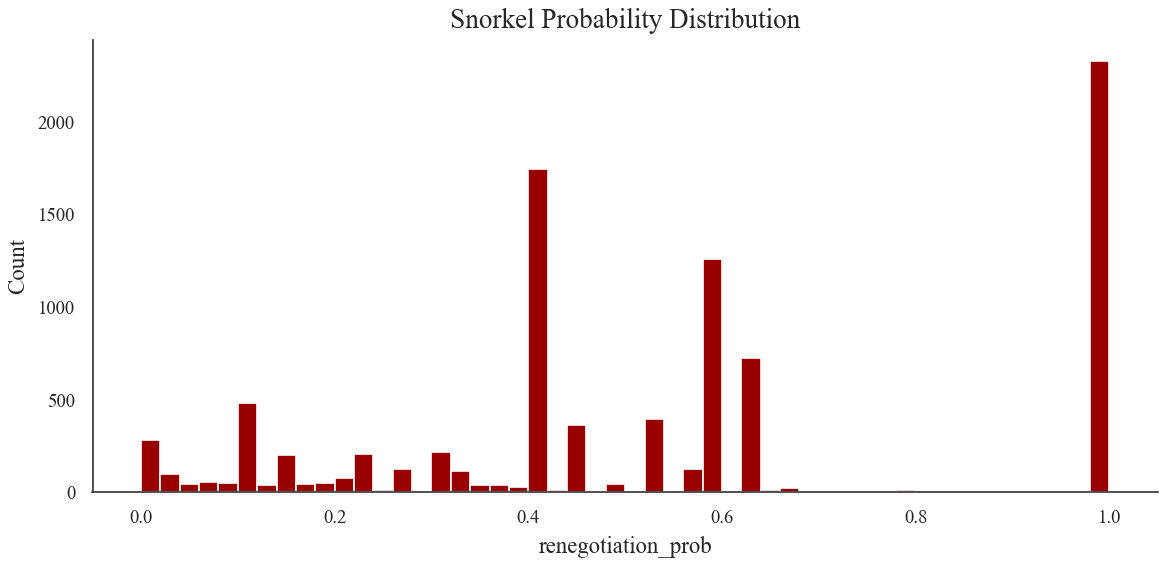

  WARN: LF vote columns not found — weak supervision audit skipped

Check 4: 0 failure(s)


In [4]:
print("=" * 60)
print("Check 4: Weak-Label Validity")
print("=" * 60)

_n_fail = 0

# Snorkel probabilities
if 'renegotiation_prob' not in df.columns:
    _fail("renegotiation_prob column absent")
    _n_fail += 1
else:
    _prob = df['renegotiation_prob'].dropna()
    _out_of_bounds = ((_prob < 0) | (_prob > 1)).sum()
    if _out_of_bounds > 0:
        _fail(f"{_out_of_bounds} renegotiation_prob values outside [0, 1]")
        _n_fail += 1
    else:
        _ok(f"renegotiation_prob: {len(_prob)} values, all in [0, 1] ✓")
    print(f"  Mean: {_prob.mean():.4f}  |  Std: {_prob.std():.4f}  |  "
          f"Null: {df['renegotiation_prob'].isna().sum()}")

    # Plot distribution
    plt.figure(figsize=(8, 4))
    plt.hist(_prob, bins=50, color=DTU_COLORS[0], edgecolor='white')
    plt.title("Snorkel Probability Distribution")
    plt.xlabel("renegotiation_prob")
    plt.ylabel("Count")
    plt.tight_layout()
    save_figure("snorkel_prob_histogram")

# LF vote columns
vote_cols = ['lf_yes_votes', 'lf_no_votes', 'lf_abstain_votes']
available_votes = [c for c in vote_cols if c in df.columns]
if not available_votes:
    _warn("LF vote columns not found — weak supervision audit skipped")
else:
    display(df[available_votes].describe().round(3))
    _ok(f"LF vote columns present: {available_votes} ✓")

print(f"\nCheck 4: {_n_fail} failure(s)")

## 5. Multi-View Feature Completeness

Checks: all required feature columns for Stage 2 are present, multi-view groups (financial, ESG, news, market, macro/logistics) exist, and missingness rates are within acceptable bounds.

In [5]:
print("=" * 60)
print("Check 5: Multi-View Feature Completeness")
print("=" * 60)

_n_fail = 0

# Required columns for Stage 2 pipeline
required_cols = [
    'contract_id', 'supplier_id', 'department', 'observation_year',
    'gold_y', 'renegotiation_prob',
    'LPI_Score', 'PPI_Value', 'payment_terms', 'incoterms',
]
_missing = [c for c in required_cols if c not in df.columns]
if _missing:
    _fail(f"Missing required columns: {_missing}")
    _n_fail += 1
else:
    _ok(f"All {len(required_cols)} required columns present ✓")

# Multi-view presence
views = {
    'contract_core': ['contract_id', 'supplier_id', 'department'],
    'financial': [c for c in df.columns if c.startswith('fin_')],
    'esg': [c for c in df.columns if c.startswith('esg_')],
    'news': [c for c in df.columns if c.startswith('news_')],
    'market': [c for c in df.columns if 'market' in c or c in ['avg_vol', 'price_volatility_score']],
    'macro_logistics': [c for c in df.columns if c in ['LPI_Score', 'PPI_Value', 'Customs',
                                                          'Infrastructure', 'International_Shipments']],
}
view_rows = []
for vname, vcols in views.items():
    if not vcols:
        _warn(f"View '{vname}' has no columns — feature engineering may be missing")
    _present = [c for c in vcols if c in df.columns]
    _miss_pct = (df[_present].isna().mean().mean() * 100) if _present else None
    view_rows.append({'view': vname, 'n_columns': len(_present), 'mean_missing_pct': _miss_pct})
view_df = pd.DataFrame(view_rows)
display(view_df.round(2))
save_table(view_df, "feature_view_completeness")

# High missingness flag
_high_miss = view_df[view_df['mean_missing_pct'].fillna(0) > 50]
for _, _r in _high_miss.iterrows():
    _warn(f"View '{_r['view']}' has {_r['mean_missing_pct']:.1f}% missing data")

print(f"\nCheck 5: {_n_fail} failure(s)")

Check 5: Multi-View Feature Completeness
  OK  : All 10 required columns present ✓


,view,n_columns,mean_missing_pct
0,contract_core,3,0.33
1,financial,58,40.06
2,esg,13,68.46
3,news,11,63.36
4,market,14,31.69
5,macro_logistics,5,0.79


  Saved: /Users/Thomas/Desktop/Master Thesis/reports/diagnostics/feature_view_completeness.csv
  WARN: View 'esg' has 68.5% missing data
  WARN: View 'news' has 63.4% missing data

Check 5: 0 failure(s)


## 6. Stage 2 Task Validity (k-Shot Support Count)

Checks: each department intended as a meta-training source has at least k+1 positive and k+1 negative gold labels. The target department (Logistics) must have at least 2+1 of each class to be a valid meta-test task.

In [6]:
print("=" * 60)
print("Check 6: Stage 2 Task Validity (k-Shot Support)")
print("=" * 60)

_n_fail = 0

def determine_role(row):
    if row['department'] == 'Logistics':
        return 'target_department'
    if row.get('gold_yes', 0) == 0 or row.get('gold_no', 0) == 0:
        return 'invalid_one_class'
    return 'source_task'

validity = gold_dist.copy()
validity['role'] = validity.apply(determine_role, axis=1)
for k in [1, 2, 5]:
    validity[f'valid_k{k}'] = (
        (validity['gold_yes'] >= k + 1) & (validity['gold_no'] >= k + 1)
    )
display(validity)
save_table(validity, "task_validity")

# Check meta-test target department
_logistics = validity[validity['department'] == 'Logistics']
if _logistics.empty:
    _fail("Logistics department not found in gold_dist")
    _n_fail += 1
else:
    _log = _logistics.iloc[0]
    if _log.get('valid_k2', False):
        _ok(f"Logistics: {_log['gold_yes']} yes / {_log['gold_no']} no → valid for k=2 ✓")
    else:
        _fail(f"Logistics: {_log.get('gold_yes',0)} yes / {_log.get('gold_no',0)} no → NOT valid for k=2")
        _n_fail += 1

# k=2 valid source tasks
_valid_src_k2 = validity[(validity['role'] == 'source_task') & validity['valid_k2']]
_ok(f"{len(_valid_src_k2)} source tasks valid for k=2 ✓")
if len(_valid_src_k2) == 0:
    _fail("No valid source tasks for k=2 — meta-training not possible")
    _n_fail += 1

print(f"\nCheck 6: {_n_fail} failure(s)")

Check 6: Stage 2 Task Validity (k-Shot Support)


,department,gold_total,gold_yes,gold_no,gold_yes_rate,role,valid_k1,valid_k2,valid_k5
1,Devices & Needles,62,33,29,0.5323,source_task,True,True,True
3,Packaging Material,12,0,12,0.0000,invalid_one_class,False,False,False
2,Logistics,9,9,0,1.0000,target_department,False,False,False
0,Bioprocessing and Excipients,1,1,0,1.0000,invalid_one_class,False,False,False


  Saved: /Users/Thomas/Desktop/Master Thesis/reports/diagnostics/task_validity.csv
  FAIL: Logistics: 9 yes / 0 no → NOT valid for k=2
  OK  : 1 source tasks valid for k=2 ✓

Check 6: 1 failure(s)


## 7. Stage 1 Artifact Validity

Checks: each Stage 1 initialization condition folder (A/B/C/D) contains the required model artifacts: `mlp_pretrained.pt`, `preprocessor.joblib`, `history.csv`, `metadata.json`.

In [7]:
print("=" * 60)
print("Check 7: Stage 1 Artifact Validity")
print("=" * 60)

_n_fail = 0

_CONDITION_VARIANTS = {
    "A_weak_only":          ["condition_A_weak_only", "A_weak_only", "cond_a", "condition_a"],
    "B_gold_only":          ["condition_B_gold_only", "B_gold_only", "cond_b", "condition_b"],
    "C_hybrid":             ["condition_C_hybrid",    "C_hybrid",    "cond_c", "condition_c"],
    "D_hybrid_unweighted":  ["condition_D_hybrid_unweighted", "D_hybrid_unweighted",
                             "cond_d", "condition_d"],
}
_REQUIRED_ARTIFACTS = [
    ("mlp_pretrained.pt", "mlp_state.pt", "model.pt"),  # accept any of these
    ("preprocessor.joblib", "preprocessor.pkl"),
    ("history.csv",),
    ("metadata.json",),
]

def _find_folder(base: Path, variants):
    for v in variants:
        p = base / v
        if p.is_dir():
            return p
    return None

def _has_artifact(folder: Path, names):
    return any((folder / n).exists() for n in names)

_rows = []
for _cond, _variants in _CONDITION_VARIANTS.items():
    _folder = _find_folder(STAGE1_DIR, _variants)
    _row = {'condition': _cond, 'folder': str(_folder) if _folder else 'NOT FOUND'}
    for _art_group in _REQUIRED_ARTIFACTS:
        _primary = _art_group[0]
        _present = _has_artifact(_folder, _art_group) if _folder else False
        _row[_primary] = _present
    _rows.append(_row)

_art_df = pd.DataFrame(_rows)
display(_art_df)

_artifact_cols = [g[0] for g in _REQUIRED_ARTIFACTS]
for _, _r in _art_df.iterrows():
    _missing_arts = [c for c in _artifact_cols if not _r.get(c, False)]
    if _r['folder'] == 'NOT FOUND':
        _fail(f"Condition {_r['condition']}: folder not found")
        _n_fail += 1
    elif _missing_arts:
        _fail(f"Condition {_r['condition']}: missing artifacts {_missing_arts}")
        _n_fail += 1
    else:
        _ok(f"Condition {_r['condition']}: all artifacts present ✓")

print(f"\nCheck 7: {_n_fail} failure(s)")

Check 7: Stage 1 Artifact Validity


,condition,folder,mlp_pretrained.pt,preprocessor.joblib,history.csv,metadata.json
0,A_weak_only,/Users/Thomas/Desktop/Master Thesis/models/sta...,True,False,False,False
1,B_gold_only,/Users/Thomas/Desktop/Master Thesis/models/sta...,True,False,False,False
2,C_hybrid,/Users/Thomas/Desktop/Master Thesis/models/sta...,True,False,False,False
3,D_hybrid_unweighted,/Users/Thomas/Desktop/Master Thesis/models/sta...,True,False,False,False


  FAIL: Condition A_weak_only: missing artifacts ['preprocessor.joblib', 'history.csv', 'metadata.json']
  FAIL: Condition B_gold_only: missing artifacts ['preprocessor.joblib', 'history.csv', 'metadata.json']
  FAIL: Condition C_hybrid: missing artifacts ['preprocessor.joblib', 'history.csv', 'metadata.json']
  FAIL: Condition D_hybrid_unweighted: missing artifacts ['preprocessor.joblib', 'history.csv', 'metadata.json']

Check 7: 4 failure(s)


## 8. Stage 2 Config Validity

Checks: `experiments/stage2_config.yaml` parses cleanly, contains exactly 10 canonical presets in 4 groups, has no `synthetic_proportion=1.0`, and all department names are valid. This is a subset of `validate_stage2_config.py` for in-notebook use.

For the full validator with all 11 checks run:
```bash
python experiments/validate_stage2_config.py
```

In [8]:
print("=" * 60)
print("Check 8: Stage 2 Config Validity")
print("=" * 60)

_n_fail = 0

try:
    import yaml
except ImportError:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'pyyaml',
                    '--break-system-packages', '-q'])
    import yaml

if not YAML_PATH.exists():
    _fail(f"stage2_config.yaml not found: {YAML_PATH}")
else:
    try:
        with open(YAML_PATH) as _f:
            _cfg = yaml.safe_load(_f)
        _ok("YAML parses without error ✓")
    except Exception as _exc:
        _fail(f"YAML parse error: {_exc}")
        _n_fail += 1
        _cfg = None

    if _cfg:
        _CANONICAL_10 = {
            'quick_debug', 'stage2b_debug',
            'thesis_main', 'init_ablation', 'k_shot_label_budget',
            'maml_lr_sweep', 'maml_freeze_ablation', 'maml_mechanics_debug',
            'stage2b_smotenc', 'stage2b_label_budget',
        }
        _presets = set(_cfg.get('presets', {}))
        _missing = _CANONICAL_10 - _presets
        _extra = _presets - _CANONICAL_10
        if _missing:
            _fail(f"Missing canonical presets: {sorted(_missing)}")
            _n_fail += 1
        if _extra:
            _fail(f"Unknown presets (should be archived?): {sorted(_extra)}")
            _n_fail += 1
        if not _missing and not _extra:
            _ok(f"All 10 canonical presets present, none extra ✓")

        # No synprop=1.0
        _synprop_violations = []
        for _pname, _preset in (_cfg.get('presets') or {}).items():
            _grid = _preset.get('synthetic_proportion_grid', [])
            if 1.0 in _grid or 1 in _grid:
                _synprop_violations.append(_pname)
        if _synprop_violations:
            _fail(f"synthetic_proportion=1.0 in presets: {_synprop_violations}")
            _n_fail += 1
        else:
            _ok("No synthetic_proportion=1.0 in any preset ✓")

        # thesis_main has zero_shot
        _tm_methods = (_cfg.get('presets') or {}).get('thesis_main', {}).get('methods', [])
        if 'zero_shot' not in _tm_methods:
            _fail(f"thesis_main missing zero_shot; has: {_tm_methods}")
            _n_fail += 1
        else:
            _ok(f"thesis_main includes zero_shot ✓")

        # Dept names cross-check
_VALID_DEPTS = {'Logistics', 'Packaging Material', 'Devices & Needles', 'Bioprocessing & Raw Materials'}
for _pname, _preset in (_cfg.get('presets') or {}).items():
    _depts = _preset.get('target_departments', [])
    _bad = [d for d in _depts if d not in _VALID_DEPTS]
    if _bad:
        _fail(f"Preset '{_pname}' has invalid target_departments: {_bad}")
        _n_fail += 1

print(f"\nCheck 8: {_n_fail} failure(s)")

Check 8: Stage 2 Config Validity
  OK  : YAML parses without error ✓
  OK  : All 10 canonical presets present, none extra ✓
  OK  : No synthetic_proportion=1.0 in any preset ✓
  OK  : thesis_main includes zero_shot ✓

Check 8: 0 failure(s)


## 9. Stage 2b Accounting Validity

Checks: Stage 2b experiment folders have `support_accounting.csv` and `stage2b_config.json` (current/post-fix folders only), SMOTENC generated synthetic rows OR has a documented skip reason, and `n_query_synthetic_rows == 0` in all episodes.

This is a summary check. For the full stale-aware validator run:
```bash
python experiments/validate_stage2b_accounting.py
```

In [9]:
print("=" * 60)
print("Check 9: Stage 2b Accounting Validity")
print("=" * 60)

_n_fail = 0
_n_warn = 0

if not EXPERIMENT_ROOT.exists():
    _warn("Stage 2 experiments directory not found — Stage 2b experiments not yet run")
    _n_warn += 1
else:
    _all_dirs = [d for d in EXPERIMENT_ROOT.iterdir() if d.is_dir()]
    _s2b_dirs = [d for d in _all_dirs if 'synprop-' in d.name and 'gen-' in d.name]

    print(f"Total experiment folders: {len(_all_dirs)}")
    print(f"Stage 2b folders:         {len(_s2b_dirs)}")

    if not _s2b_dirs:
        _warn("No Stage 2b folders found — run stage2b_smotenc preset first")
        _n_warn += 1
    else:
        # Separate stale (pre-fix) from current (post-fix)
        _current = [d for d in _s2b_dirs if (d / 'stage2b_config.json').exists()]
        _stale = [d for d in _s2b_dirs if not (d / 'stage2b_config.json').exists()]

        print(f"  Current (post-fix): {len(_current)}")
        print(f"  Stale  (pre-fix):   {len(_stale)}")

        if _stale:
            _warn(f"{len(_stale)} stale folders lack stage2b_config.json — pre-date accounting fix")
            _n_warn += 1

        _smote_dirs = [d for d in _current if 'gen-smote_nc' in d.name]
        _none_dirs  = [d for d in _current if 'gen-none' in d.name]

        print(f"  Current smote_nc: {len(_smote_dirs)}")
        print(f"  Current gen-none: {len(_none_dirs)}")

        # Check 9a: accounting CSV existence
        _missing_acct = [d for d in _smote_dirs if not (d / 'support_accounting.csv').exists()]
        if _missing_acct:
            _fail(f"{len(_missing_acct)} smote_nc folders missing support_accounting.csv")
            _n_fail += 1
        elif _smote_dirs:
            _ok(f"All {len(_smote_dirs)} smote_nc folders have support_accounting.csv ✓")

        # Check 9b: n_synthetic_support_rows > 0 or skip reason
        _zero_no_reason = 0
        _zero_with_reason = 0
        _fired = 0
        for _d in _smote_dirs:
            _ap = _d / 'support_accounting.csv'
            if not _ap.exists():
                continue
            try:
                _acct = pd.read_csv(_ap)
            except Exception:
                continue
            if 'n_synthetic_support_rows' not in _acct.columns:
                continue
            if (_acct['n_synthetic_support_rows'] == 0).all():
                import json as _json
                _skip = ''
                _cfg_path = _d / 'stage2b_config.json'
                if _cfg_path.exists():
                    try:
                        _skip = _json.load(open(_cfg_path)).get('gen_skip_reason', '')
                    except Exception:
                        pass
                if _skip:
                    _zero_with_reason += 1
                else:
                    _zero_no_reason += 1
            else:
                _fired += 1

        if _fired > 0:
            _ok(f"{_fired} smote_nc folders generated synthetic rows ✓")
        if _zero_with_reason > 0:
            _warn(f"{_zero_with_reason} smote_nc folder(s) have 0 synthetic rows with documented skip reason (OK)")
            _n_warn += _zero_with_reason
        if _zero_no_reason > 0:
            _fail(f"{_zero_no_reason} smote_nc folder(s) have 0 synthetic rows AND no skip reason — SMOTENC silently did nothing")
            _n_fail += 1

        # Check 9c: n_query_synthetic_rows == 0
        _query_violations = 0
        for _d in _smote_dirs + _none_dirs:
            _ap = _d / 'support_accounting.csv'
            if not _ap.exists():
                continue
            try:
                _acct = pd.read_csv(_ap)
            except Exception:
                continue
            if 'n_query_synthetic_rows' in _acct.columns and (_acct['n_query_synthetic_rows'] > 0).any():
                _fail(f"{_d.name}: n_query_synthetic_rows > 0 — synthetic rows in query set!")
                _query_violations += 1
                _n_fail += 1
        if _query_violations == 0:
            _ok("n_query_synthetic_rows == 0 in all current folders ✓")

print(f"\nCheck 9: {_n_fail} failure(s), {_n_warn} warning(s)")

Check 9: Stage 2b Accounting Validity
Total experiment folders: 367
Stage 2b folders:         112
  Current (post-fix): 32
  Stale  (pre-fix):   80
  WARN: 80 stale folders lack stage2b_config.json — pre-date accounting fix
  Current smote_nc: 32
  Current gen-none: 0
  OK  : All 32 smote_nc folders have support_accounting.csv ✓
  OK  : 28 smote_nc folders generated synthetic rows ✓
  WARN: 4 smote_nc folder(s) have 0 synthetic rows with documented skip reason (OK)
  OK  : n_query_synthetic_rows == 0 in all current folders ✓

Check 9: 0 failure(s), 5 warning(s)


---

## Executive Summary

Run all sections above, then execute the cell below for a combined pass/fail summary.

For a standalone command-line validity check run:
```bash
python experiments/validate_stage2_config.py   # config check (11 checks)
python experiments/validate_stage2b_accounting.py  # accounting check
```

In [10]:
print("--- EXECUTIVE SUMMARY ---")
print(f"Dataset: {DATA_PATH.name}")
print(f"Shape: {df.shape}")
print(f"Departments: {df['department'].nunique()}")
if 'gold_y' in df.columns:
    _gl = df['gold_y'].notnull().sum()
    _yes = int(df['gold_y'].sum())
    _no = _gl - _yes
    print(f"Gold labels: {_gl} ({_yes} yes / {_no} no)")
print()
print("Stage 1 conditions expected:  A_weak_only / B_gold_only / C_hybrid / D_hybrid_unweighted")
print("Stage 2 canonical presets:    10 (in 4 groups — see experiments/stage2_config.yaml)")
print()
print("Run sections 2-9 to see pass/fail status for each check.")
print("All checks passed = pipeline is ready to run.")

--- EXECUTIVE SUMMARY ---
Dataset: contract_with_features_labeled.csv
Shape: (9201, 165)
Departments: 14
Gold labels: 84 (43 yes / 41 no)

Stage 1 conditions expected:  A_weak_only / B_gold_only / C_hybrid / D_hybrid_unweighted
Stage 2 canonical presets:    10 (in 4 groups — see experiments/stage2_config.yaml)

Run sections 2-9 to see pass/fail status for each check.
All checks passed = pipeline is ready to run.
